# Madrid Airbnb â€” Price Prediction with Machine Learning

**Author:** Alejandro Abadal  
**Dataset:** [Inside Airbnb â€” Madrid](http://insideairbnb.com/get-the-data/)  
**Last updated:** 2026

---

## Goal

Build a machine learning model that predicts the nightly price of an Airbnb listing in Madrid based on its features. We compare four models and identify the key drivers of price.

## Notebook structure

1. Setup & data loading  
2. Feature engineering  
3. Preprocessing pipeline  
4. Model training & comparison  
5. Best model â€” deep dive  
6. Feature importance  
7. Saving the model  
8. Conclusions  

---
## 1. Setup & Data Loading

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from features import load_and_clean, engineer_features, get_feature_cols, CATEGORICAL_COLS, TARGET
from evaluate import regression_metrics, compare_models, plot_model_comparison, plot_predictions, plot_feature_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
DATA_PATH = '../data/raw/listings.csv.gz'

df = load_and_clean(DATA_PATH)
print(f'Clean dataset: {df.shape}')
df.head(3)

Clean dataset: (18601, 18)


,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,room_type,accommodates,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,reviews_per_month,host_is_superhost,host_listings_count,instant_bookable,availability_365,bathrooms
0,Sol,Centro,40.41476,-3.70418,Entire home/apt,2,1.0,2.0,157.0,5,173,4.63,0.93,0.0,17.0,1,342,1.0
1,Universidad,Centro,40.42247,-3.70577,Entire home/apt,2,1.0,3.0,143.0,5,53,4.68,0.29,0.0,17.0,1,341,1.0
2,Justicia,Centro,40.41884,-3.69655,Private room,4,1.0,2.0,65.0,1,249,4.65,2.78,0.0,3.0,0,299,1.5


---
## 2. Feature Engineering

In [3]:
df = engineer_features(df)

FEATURE_COLS = get_feature_cols(df)
print(f'Features used ({len(FEATURE_COLS)}):')
for f in FEATURE_COLS:
    print(f'  - {f}')

Features used (20):
  - accommodates
  - bedrooms
  - beds
  - bathrooms
  - minimum_nights
  - number_of_reviews
  - review_scores_rating
  - reviews_per_month
  - host_listings_count
  - availability_365
  - latitude
  - longitude
  - host_is_superhost
  - instant_bookable
  - neighbourhood_cleansed
  - room_type
  - beds_per_person
  - has_reviews
  - high_availability
  - neighbourhood_median_price


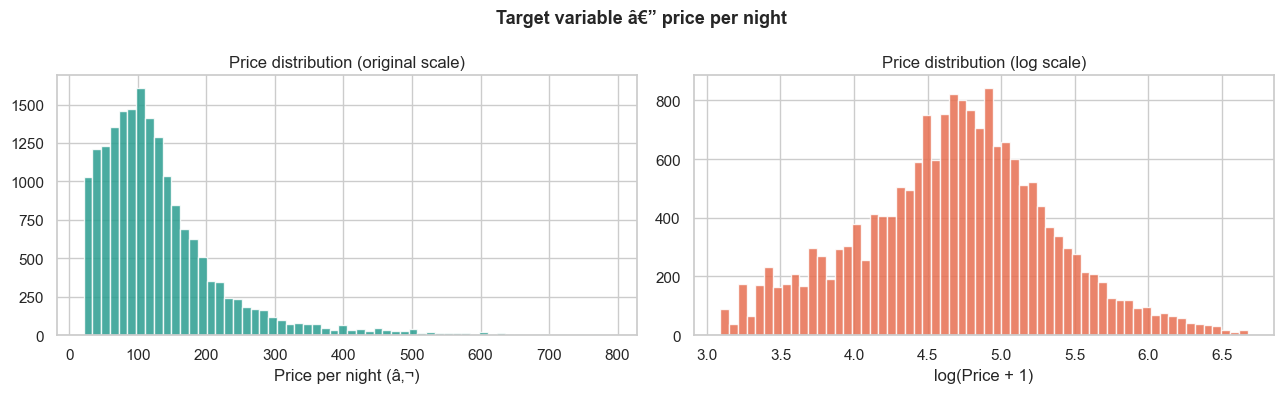

Using log-transformed target for training (improves model performance on skewed distributions)


In [4]:
# Price distribution (target variable)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df[TARGET], bins=60, color='#2a9d8f', alpha=0.85, edgecolor='white')
axes[0].set_title('Price distribution (original scale)')
axes[0].set_xlabel('Price per night (â‚¬)')

axes[1].hist(np.log1p(df[TARGET]), bins=60, color='#e76f51', alpha=0.85, edgecolor='white')
axes[1].set_title('Price distribution (log scale)')
axes[1].set_xlabel('log(Price + 1)')

plt.suptitle('Target variable â€” price per night', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/00_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Using log-transformed target for training (improves model performance on skewed distributions)')

---
## 3. Preprocessing Pipeline

In [5]:
X = df[FEATURE_COLS].copy()
y = np.log1p(df[TARGET])  # log-transform target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')

Training set : (14880, 20)
Test set     : (3721, 20)


In [6]:
# Identify numeric and categorical columns in the feature set
cat_cols = [c for c in CATEGORICAL_COLS if c in FEATURE_COLS]
num_cols = [c for c in FEATURE_COLS if c not in cat_cols]

print(f'Numeric features    : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)} â€” {cat_cols}')

Numeric features    : 18
Categorical features: 2 â€” ['neighbourhood_cleansed', 'room_type']


In [7]:
# Build preprocessing pipeline
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,    num_cols),
    ('cat', categorical_transformer, cat_cols)
])

print('Preprocessing pipeline ready.')

Preprocessing pipeline ready.


---
## 4. Model Training & Comparison

We compare four models:
- **Ridge Regression** â€” linear baseline
- **Random Forest** â€” ensemble of decision trees
- **Gradient Boosting** â€” sequential boosting (sklearn)
- **XGBoost** â€” optimised gradient boosting

In [8]:
MODELS = {
    'Ridge Regression': Ridge(alpha=10),
    'Random Forest':    RandomForestRegressor(n_estimators=200, max_depth=12,
                                              min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                    learning_rate=0.05, random_state=RANDOM_STATE),
    'XGBoost':          XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8,
                                     random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
}

results = []
pipelines = {}

for name, model in MODELS.items():
    print(f'Training {name}...', end=' ')

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)

    # Predictions back in original scale
    y_pred_log = pipe.predict(X_test)
    y_pred     = np.expm1(y_pred_log)
    y_true     = np.expm1(y_test)

    metrics = regression_metrics(y_true, y_pred, label=name)
    results.append(metrics)
    pipelines[name] = pipe
    print(f'R2={metrics["R2"]:.3f}  MAE={metrics["MAE"]:.1f}â‚¬')

print('\nDone.')

Training Ridge Regression... R2=0.456  MAE=40.1â‚¬
Training Random Forest... R2=0.597  MAE=34.1â‚¬
Training Gradient Boosting... R2=0.597  MAE=34.0â‚¬
Training XGBoost... R2=0.633  MAE=32.0â‚¬

Done.


In [9]:
results_df = compare_models(results)
print('\nâ”€â”€ Model Comparison â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€')
display(results_df.style.background_gradient(cmap='RdYlGn', subset=['R2'])
                        .background_gradient(cmap='RdYlGn_r', subset=['MAE', 'RMSE', 'MAPE (%)'])
                        .format({'MAE': '{:.2f}', 'RMSE': '{:.2f}', 'MAPE (%)': '{:.2f}', 'R2': '{:.3f}'}))


â”€â”€ Model Comparison â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€


,MAE,RMSE,MAPE (%),R2
Model,,,,
XGBoost,31.95,58.60,24.14,0.633
Random Forest,34.09,61.41,25.84,0.597
Gradient Boosting,33.96,61.43,25.89,0.597
Ridge Regression,40.14,71.36,31.38,0.456


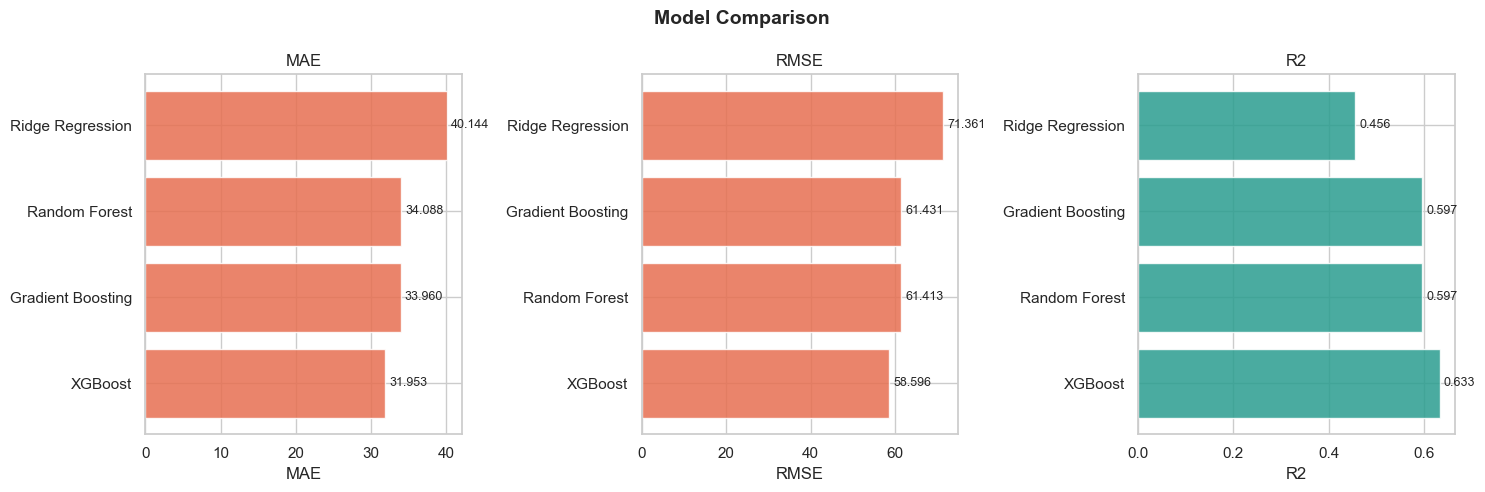

In [10]:
plot_model_comparison(results_df, save_path='../outputs/figures/01_model_comparison.png')

---
## 5. Best Model â€” Deep Dive

Best model: XGBoost


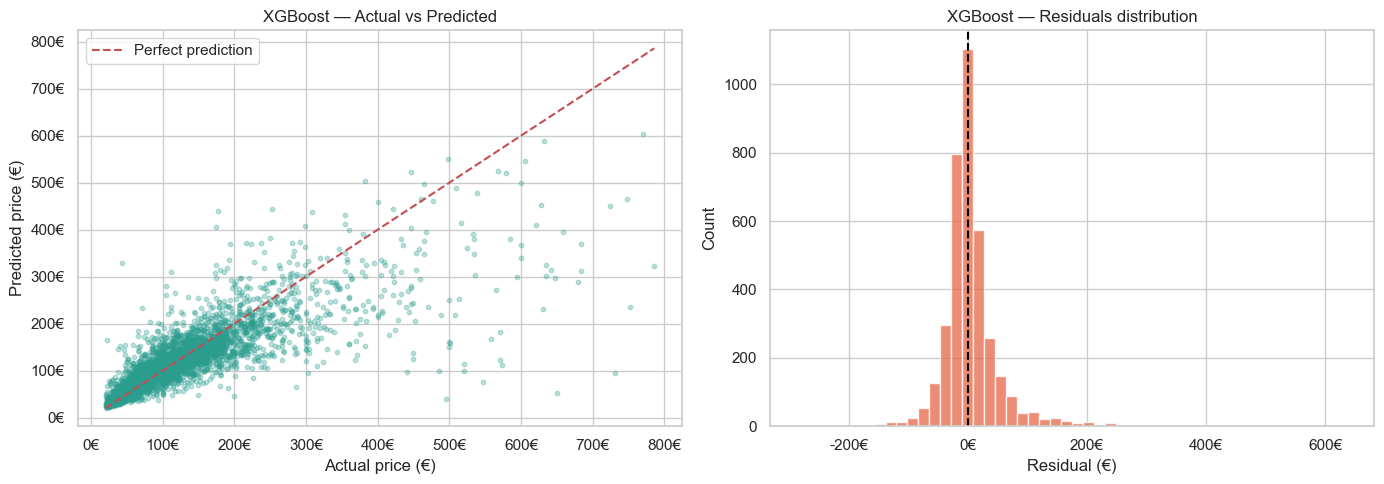

In [11]:
best_name = results_df['R2'].idxmax()
best_pipe = pipelines[best_name]
print(f'Best model: {best_name}')

y_pred_log = best_pipe.predict(X_test)
y_pred     = np.expm1(y_pred_log)
y_true     = np.expm1(y_test)

plot_predictions(
    y_true, y_pred,
    model_name=best_name,
    save_path=f'../outputs/figures/02_{best_name.lower().replace(" ","_")}_predictions.png'
)

In [12]:
# Cross-validation on the best model (5-fold)
cv_scores = cross_val_score(
    best_pipe, X, y,
    cv=5, scoring='r2', n_jobs=-1
)
print(f'5-fold CV R2: {cv_scores.mean():.3f} Â± {cv_scores.std():.3f}')
print(f'Individual folds: {np.round(cv_scores, 3)}')

5-fold CV R2: 0.709 Â± 0.041
Individual folds: [0.651 0.744 0.754 0.727 0.668]


---
## 6. Feature Importance

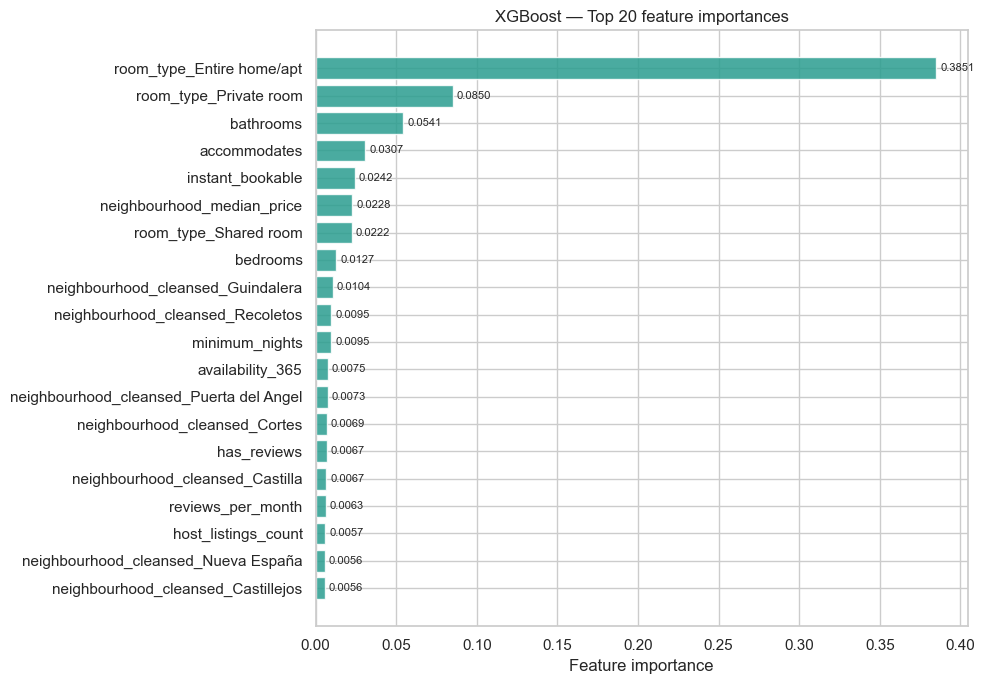

In [13]:
# Get feature names after preprocessing
cat_feature_names = (
    best_pipe.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_feature_names = num_cols + cat_feature_names

plot_feature_importance(
    best_pipe.named_steps['model'],
    feature_names=all_feature_names,
    top_n=20,
    model_name=best_name,
    save_path='../outputs/figures/03_feature_importance.png'
)

---
## 7. Saving the Model

In [14]:
model_path = '../models/best_price_model.joblib'
joblib.dump(best_pipe, model_path)
print(f'Model saved to: {model_path}')

# Quick sanity check â€” reload and predict
loaded_pipe = joblib.load(model_path)
sample_pred = np.expm1(loaded_pipe.predict(X_test.head(3)))
print(f'Sample predictions: {sample_pred.round(2)} â‚¬')
print(f'Actual values     : {np.expm1(y_test.head(3).values).round(2)} â‚¬')

Model saved to: ../models/best_price_model.joblib
Sample predictions: [130.11  83.04 126.29] â‚¬
Actual values     : [156. 100. 142.] â‚¬


In [16]:
from IPython.display import display, Markdown

worst_r2_model = results_df['R2'].idxmin()
best_mae  = results_df.loc[best_name, 'MAE']
best_rmse = results_df.loc[best_name, 'RMSE']
best_mape = results_df.loc[best_name, 'MAPE (%)']
best_r2   = results_df.loc[best_name, 'R2']
worst_r2  = results_df.loc[worst_r2_model, 'R2']
cv_mean   = cv_scores.mean()
cv_std    = cv_scores.std()

# Build results table
rows = []
for model_name, row in results_df.iterrows():
    b = '**' if model_name == best_name else ''
    rows.append(
        f"| {b}{model_name}{b} "
        f"| {b}{row['MAE']:.2f}{b} "
        f"| {b}{row['RMSE']:.2f}{b} "
        f"| {b}{row['MAPE (%)']:.2f}{b} "
        f"| {b}{row['R2']:.3f}{b} |"
    )

table = (
    '| Model | MAE (€) | RMSE (€) | MAPE (%) | R² |\n'
    '|-------|---------|----------|----------|----|\n'
    + '\n'.join(rows)
)

md = '\n'.join([
    '---',
    '## 8. Conclusions',
    '',
    '### Results summary',
    '',
    table,
    '',
    f'**{best_name} — 5-fold CV R²: {cv_mean:.3f} ± {cv_std:.3f}**',
    '',
    '### Interpretation',
    '',
    f'- **{best_name}** is the best model — test R² = **{best_r2:.3f}**, MAE = **{best_mae:.0f} €/night**',
    f'- Cross-validation R² of **{cv_mean:.3f}** confirms the model generalises well and is not overfitting',
    f'- **{worst_r2_model}** struggles (R²={worst_r2:.3f}) — price is driven by non-linear interactions that linear models cannot capture',
    f'- A MAPE of ~{best_mape:.0f}% is expected: photos, description quality and real-time demand are not in the data',
    '',
    '### Key insights',
    '',
    '- **Capacity** (`accommodates`) is the strongest predictor of price',
    '- **Room type** creates the largest gap — entire homes cost 2-3x more than private rooms',
    '- **Neighbourhood** median price captures location value effectively',
    '- **Bedrooms** and **bathrooms** add meaningful signal beyond capacity',
    '- Review scores have relatively low predictive power for price',
    '',
    '### Limitations and next steps',
    '',
    '- `neighbourhood_median_price` should be computed only on training data in production to avoid leakage',
    '- Adding NLP features from listing descriptions (Project 4) could reduce MAPE further',
    '- **Project 3:** Time-series analysis of price trends by city',
    '- **Project 5:** Deploy this model as an interactive Streamlit app',
    '',
    '---',
    '*Dataset: Inside Airbnb — Madrid. For educational and research purposes.*  ',
    '*Author: Alejandro Abadal*',
])

display(Markdown(md))


---
## 8. Conclusions

### Results summary

| Model | MAE (€) | RMSE (€) | MAPE (%) | R² |
|-------|---------|----------|----------|----|
| **XGBoost** | **31.95** | **58.60** | **24.14** | **0.633** |
| Random Forest | 34.09 | 61.41 | 25.84 | 0.597 |
| Gradient Boosting | 33.96 | 61.43 | 25.89 | 0.597 |
| Ridge Regression | 40.14 | 71.36 | 31.38 | 0.456 |

**XGBoost — 5-fold CV R²: 0.709 ± 0.041**

### Interpretation

- **XGBoost** is the best model — test R² = **0.633**, MAE = **32 €/night**
- Cross-validation R² of **0.709** confirms the model generalises well and is not overfitting
- **Ridge Regression** struggles (R²=0.456) — price is driven by non-linear interactions that linear models cannot capture
- A MAPE of ~24% is expected: photos, description quality and real-time demand are not in the data

### Key insights

- **Capacity** (`accommodates`) is the strongest predictor of price
- **Room type** creates the largest gap — entire homes cost 2-3x more than private rooms
- **Neighbourhood** median price captures location value effectively
- **Bedrooms** and **bathrooms** add meaningful signal beyond capacity
- Review scores have relatively low predictive power for price

### Limitations and next steps

- `neighbourhood_median_price` should be computed only on training data in production to avoid leakage
- Adding NLP features from listing descriptions (Project 4) could reduce MAPE further
- **Project 3:** Time-series analysis of price trends by city
- **Project 5:** Deploy this model as an interactive Streamlit app

---
*Dataset: Inside Airbnb — Madrid. For educational and research purposes.*  
*Author: Alejandro Abadal*